In [2]:
print("Jupyter is working!")

Jupyter is working!


print("TEST")

In [3]:
import pandas as pd

file_path = r"C:\Users\Shivani Singh\Downloads\loan approval.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,ApplicantID,Age,AnnualIncome,LoanAmount,CreditScore,EmploymentYears,Education,MaritalStatus,PropertyArea,SelfEmployed,LoanApproved
0,L0001,25,35200,30000,703,7.4,Graduate,Married,Rural,No,Y
1,L0002,55,38300,133000,712,2.1,Graduate,Married,Urban,No,N
2,L0003,50,35800,95000,678,10.9,Graduate,Married,Semiurban,Yes,Y
3,L0004,40,43000,103000,694,5.2,Graduate,Married,Semiurban,No,N
4,L0005,40,77800,84000,728,3.4,Not Graduate,Divorced,Urban,No,N


In [5]:
print(df.columns.tolist())


['ApplicantID', 'Age', 'AnnualIncome', 'LoanAmount', 'CreditScore', 'EmploymentYears', 'Education', 'MaritalStatus', 'PropertyArea', 'SelfEmployed', 'LoanApproved']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ApplicantID      600 non-null    object 
 1   Age              600 non-null    int64  
 2   AnnualIncome     600 non-null    int64  
 3   LoanAmount       600 non-null    int64  
 4   CreditScore      600 non-null    int64  
 5   EmploymentYears  600 non-null    float64
 6   Education        600 non-null    object 
 7   MaritalStatus    600 non-null    object 
 8   PropertyArea     600 non-null    object 
 9   SelfEmployed     600 non-null    object 
 10  LoanApproved     600 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 51.7+ KB


In [7]:
print(df['LoanApproved'].value_counts())

LoanApproved
N    334
Y    266
Name: count, dtype: int64


In [8]:
total = len(df)

p_N = 334 / total
p_Y = 266 / total

print("Probability of N:", p_N)
print("Probability of Y:", p_Y)


Probability of N: 0.5566666666666666
Probability of Y: 0.44333333333333336


In [9]:
import math

entropy_loan = -(p_N * math.log2(p_N) + p_Y * math.log2(p_Y))

print("Entropy of LoanApproved:", entropy_loan)

Entropy of LoanApproved: 0.9907147546131312


In [10]:
print(df['Education'].value_counts())

Education
Graduate        429
Not Graduate    171
Name: count, dtype: int64


In [11]:
pd.crosstab(df['Education'], df['LoanApproved'])

LoanApproved,N,Y
Education,,
Graduate,216,213
Not Graduate,118,53


In [12]:
import math

# Graduate
graduate_total = 216 + 213
p_N_grad = 216 / graduate_total
p_Y_grad = 213 / graduate_total

entropy_grad = -(p_N_grad * math.log2(p_N_grad) +
                 p_Y_grad * math.log2(p_Y_grad))

# Not Graduate
not_grad_total = 118 + 53
p_N_not = 118 / not_grad_total
p_Y_not = 53 / not_grad_total

entropy_not_grad = -(p_N_not * math.log2(p_N_not) +
                     p_Y_not * math.log2(p_Y_not))

print("Entropy of Graduate:", entropy_grad)
print("Entropy of Not Graduate:", entropy_not_grad)

Entropy of Graduate: 0.9999647242701452
Entropy of Not Graduate: 0.8931059422745129


In [13]:
# Weighted Entropy for Education

weighted_entropy = (
    (graduate_total / total) * entropy_grad +
    (not_grad_total / total) * entropy_not_grad
)

print("Weighted Entropy:", weighted_entropy)

Weighted Entropy: 0.96950997140139


In [14]:
# Information Gain for Education

information_gain_education = entropy_loan - weighted_entropy

print("Information Gain for Education:", information_gain_education)

Information Gain for Education: 0.02120478321174124


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
# Make a copy of the dataset
data = df.copy()

# Remove ApplicantID because it is only an ID
data = data.drop('ApplicantID', axis=1)

# Convert categorical columns into numbers
categorical_cols = ['Education', 'MaritalStatus', 'PropertyArea', 'SelfEmployed']

le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Convert target variable LoanApproved into numbers
data['LoanApproved'] = le.fit_transform(data['LoanApproved'])

print(data.head())

   Age  AnnualIncome  LoanAmount  CreditScore  EmploymentYears  Education  \
0   25         35200       30000          703              7.4          0   
1   55         38300      133000          712              2.1          0   
2   50         35800       95000          678             10.9          0   
3   40         43000      103000          694              5.2          0   
4   40         77800       84000          728              3.4          1   

   MaritalStatus  PropertyArea  SelfEmployed  LoanApproved  
0              1             0             0             1  
1              1             2             0             0  
2              1             1             1             1  
3              1             1             0             0  
4              0             2             0             0  


In [18]:
# Input features
X = data.drop('LoanApproved', axis=1)

# Target variable
y = data['LoanApproved']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (600, 9)
y shape: (600,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (480, 9)
Testing data: (120, 9)


In [20]:
# Create Decision Tree using Entropy
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [21]:
# Predict on testing data
y_pred_dt = dt_model.predict(X_test)

print("Predictions:")
print(y_pred_dt)

Predictions:
[0 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 1 0 1 0 1 0 1 0 0 1 1 1 1
 1 0 1 0 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 1 1 1 1 1 0
 0 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0
 1 0 0 0 0 0 1 1 0]


In [22]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Decision Tree Accuracy (%):", accuracy_dt * 100)

Decision Tree Accuracy: 0.675
Decision Tree Accuracy (%): 67.5


In [23]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

Confusion Matrix:
[[47 20]
 [19 34]]


In [24]:
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.70      0.71        67
           1       0.63      0.64      0.64        53

    accuracy                           0.68       120
   macro avg       0.67      0.67      0.67       120
weighted avg       0.68      0.68      0.68       120



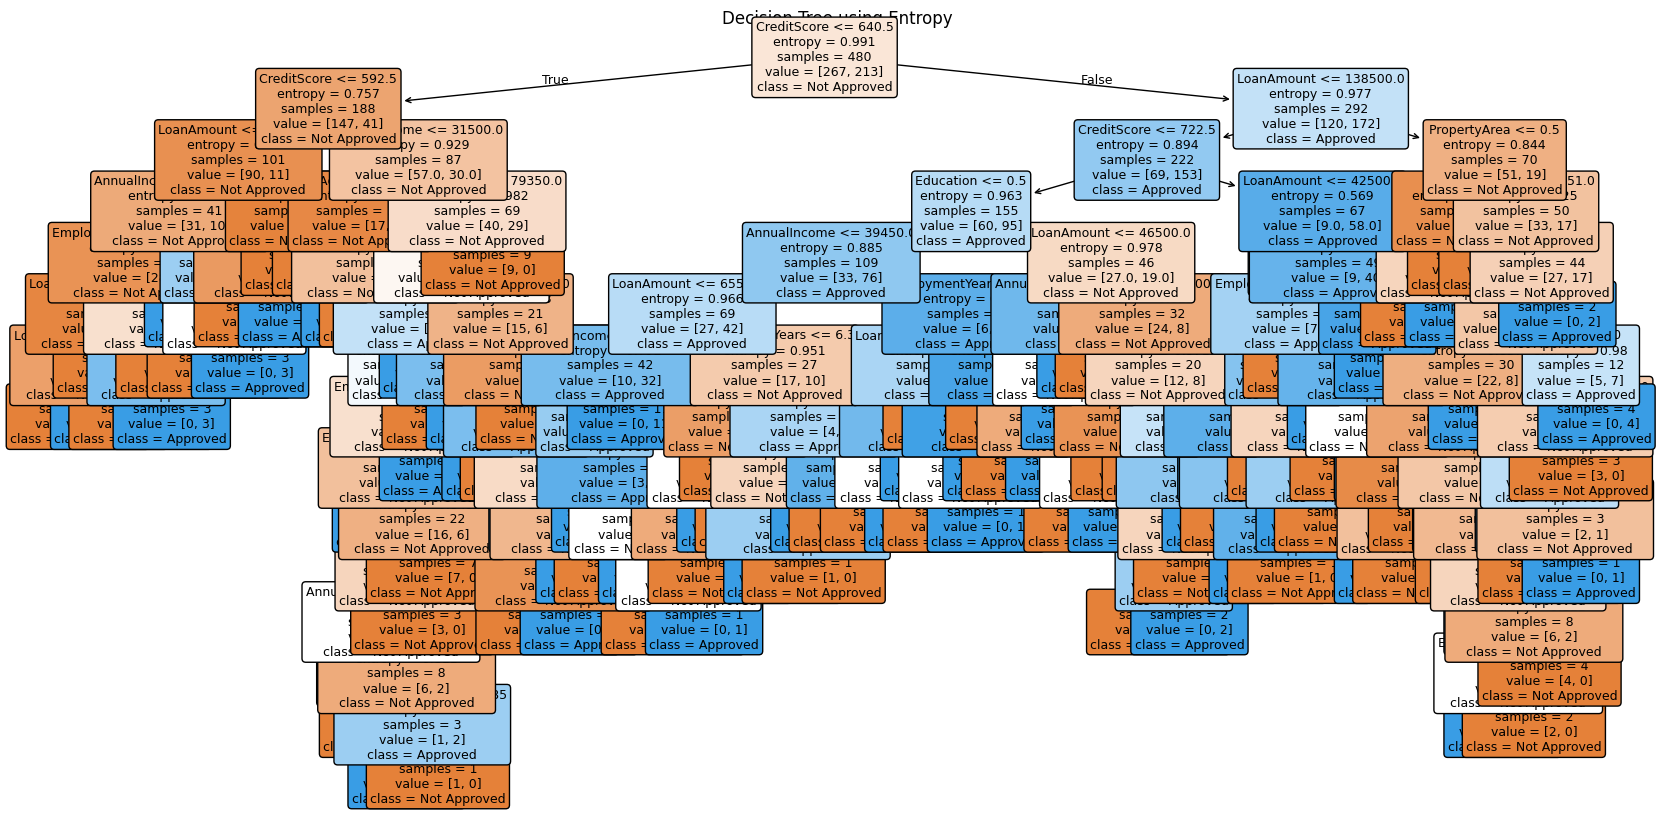

In [25]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Not Approved', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree using Entropy")
plt.show()

In [26]:
from sklearn.naive_bayes import GaussianNB

# Create Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [27]:
# Predict on testing data
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Predictions:")
print(y_pred_nb)

Naive Bayes Predictions:
[1 0 1 1 0 1 0 1 1 0 0 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 0 1 0 1 1 0 0 0 1 0 1
 1 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0
 1 0 0 1 1 1 0 1 0 0 0 1 0 0 1 1 1 0 0 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0 1 0
 1 0 0 0 1 1 0 1 0]


In [28]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print("Naive Bayes Accuracy (%):", accuracy_nb * 100)

Naive Bayes Accuracy: 0.5916666666666667
Naive Bayes Accuracy (%): 59.166666666666664


In [29]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Naive Bayes Confusion Matrix:")
print(cm_nb)

Naive Bayes Confusion Matrix:
[[34 33]
 [16 37]]


In [30]:
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.51      0.58        67
           1       0.53      0.70      0.60        53

    accuracy                           0.59       120
   macro avg       0.60      0.60      0.59       120
weighted avg       0.61      0.59      0.59       120



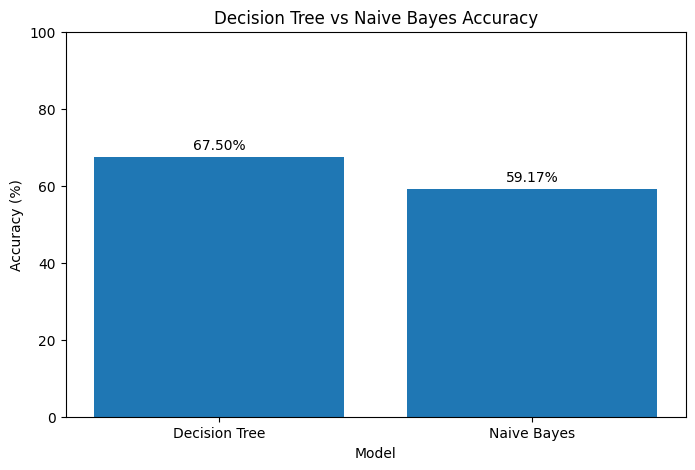

In [31]:
models = ['Decision Tree', 'Naive Bayes']
accuracies = [accuracy_dt * 100, accuracy_nb * 100]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.title('Decision Tree vs Naive Bayes Accuracy')
plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(i, value + 2, f'{value:.2f}%', ha='center')

plt.show()

In [32]:
# Take the first applicant from the dataset
applicant = X.iloc[[0]]

# Decision Tree prediction
dt_prediction = dt_model.predict(applicant)[0]

# Prediction probability
dt_probability = dt_model.predict_proba(applicant)[0]

if dt_prediction == 1:
    result = "Loan Approved"
else:
    result = "Loan Not Approved"

print("Decision Tree Prediction:", result)
print("Probability of Not Approved:", dt_probability[0])
print("Probability of Approved:", dt_probability[1])

Decision Tree Prediction: Loan Approved
Probability of Not Approved: 0.0
Probability of Approved: 1.0


In [33]:
root_feature = X.columns[dt_model.tree_.feature[0]]

print("Root Feature of Decision Tree:", root_feature)

Root Feature of Decision Tree: CreditScore


In [34]:
root_index = dt_model.tree_.feature[0]
root_threshold = dt_model.tree_.threshold[0]

print("Root Feature:", X.columns[root_index])
print("Root Threshold:", root_threshold)

Root Feature: CreditScore
Root Threshold: 640.5
